In [31]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pca import pca
import matplotlib.pyplot as plt
import os
os.chdir("D:/Machine_Learning/Datasets/")
import warnings
warnings.filterwarnings('ignore')

In [32]:
nut = pd.read_csv(r"../Datasets/nutrient.csv", index_col=0)
nut.shape

(27, 5)

In [33]:
scaler = StandardScaler().set_output(transform='pandas')
nut_scaled = scaler.fit_transform(nut)

In [34]:
prcomp = PCA().set_output(transform='pandas')
pc_data = prcomp.fit_transform(nut_scaled)
pc_data.var()   #PC0 > PC1 > .....> PC4

pca0    2.280797
pca1    1.189962
pca2    0.880318
pca3    0.839567
pca4    0.001663
dtype: float64

In [35]:
pc_data

,pca0,pca1,pca2,pca3,pca4
Food_Item,,,,,
BEEF BRAISED,1.894907,0.318029,-0.003579,0.327156,0.005915
HAMBURGER,0.659812,-0.079563,-0.512841,0.166202,-0.002632
BEEF ROAST,2.936755,1.122724,1.097788,-0.226335,0.003483
BEEF STEAK,2.321069,0.585663,0.239173,0.318095,0.028400
BEEF CANNED,-0.256477,0.054382,-1.168707,0.474857,-0.042641
CHICKEN BROILED,-0.932996,-0.905719,-0.393767,-0.815849,-0.031897
CHICKEN CANNED,-0.185016,-1.564189,-0.789681,0.039419,-0.015362
BEEF HEART,-0.699024,0.346282,-2.595080,1.568667,0.045738
LAMB LEG ROAST,0.937389,0.108904,-0.274877,0.082978,-0.024877


In [36]:
values, vectors = np.linalg.eig(nut_scaled.cov())
print("Eigen Values: ",values)

Eigen Values:  [2.28079741e+00 1.66325132e-03 1.18996245e+00 8.39566765e-01
 8.80317810e-01]


In [37]:
vectors

array([[-0.65428251, -0.7092977 , -0.08533006,  0.19703438, -0.15068976],
       [-0.15073191,  0.10406865,  0.68933242,  0.52649179,  0.46268437],
       [-0.63991067,  0.69710352, -0.19978707,  0.13170953, -0.21748273],
       [ 0.35497845, -0.00316007,  0.00314436,  0.67057536, -0.65138247],
       [ 0.11704241, -0.01015761, -0.69109684,  0.46579517,  0.54001659]])

In [38]:
prcomp.components_

array([[ 0.65428251,  0.15073191,  0.63991067, -0.35497845, -0.11704241],
       [ 0.08533006, -0.68933242,  0.19978707, -0.00314436,  0.69109684],
       [ 0.15068976, -0.46268437,  0.21748273,  0.65138247, -0.54001659],
       [ 0.19703438,  0.52649179,  0.13170953,  0.67057536,  0.46579517],
       [ 0.7092977 , -0.10406865, -0.69710352,  0.00316007,  0.01015761]])

[24-04-2026 16:28:07] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[24-04-2026 16:28:07] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:28:07] [pca.pca] [INFO] The top 4 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:28:07] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[24-04-2026 16:28:07] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:28:07] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[24-04-2026 16:28:07] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:28:07] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

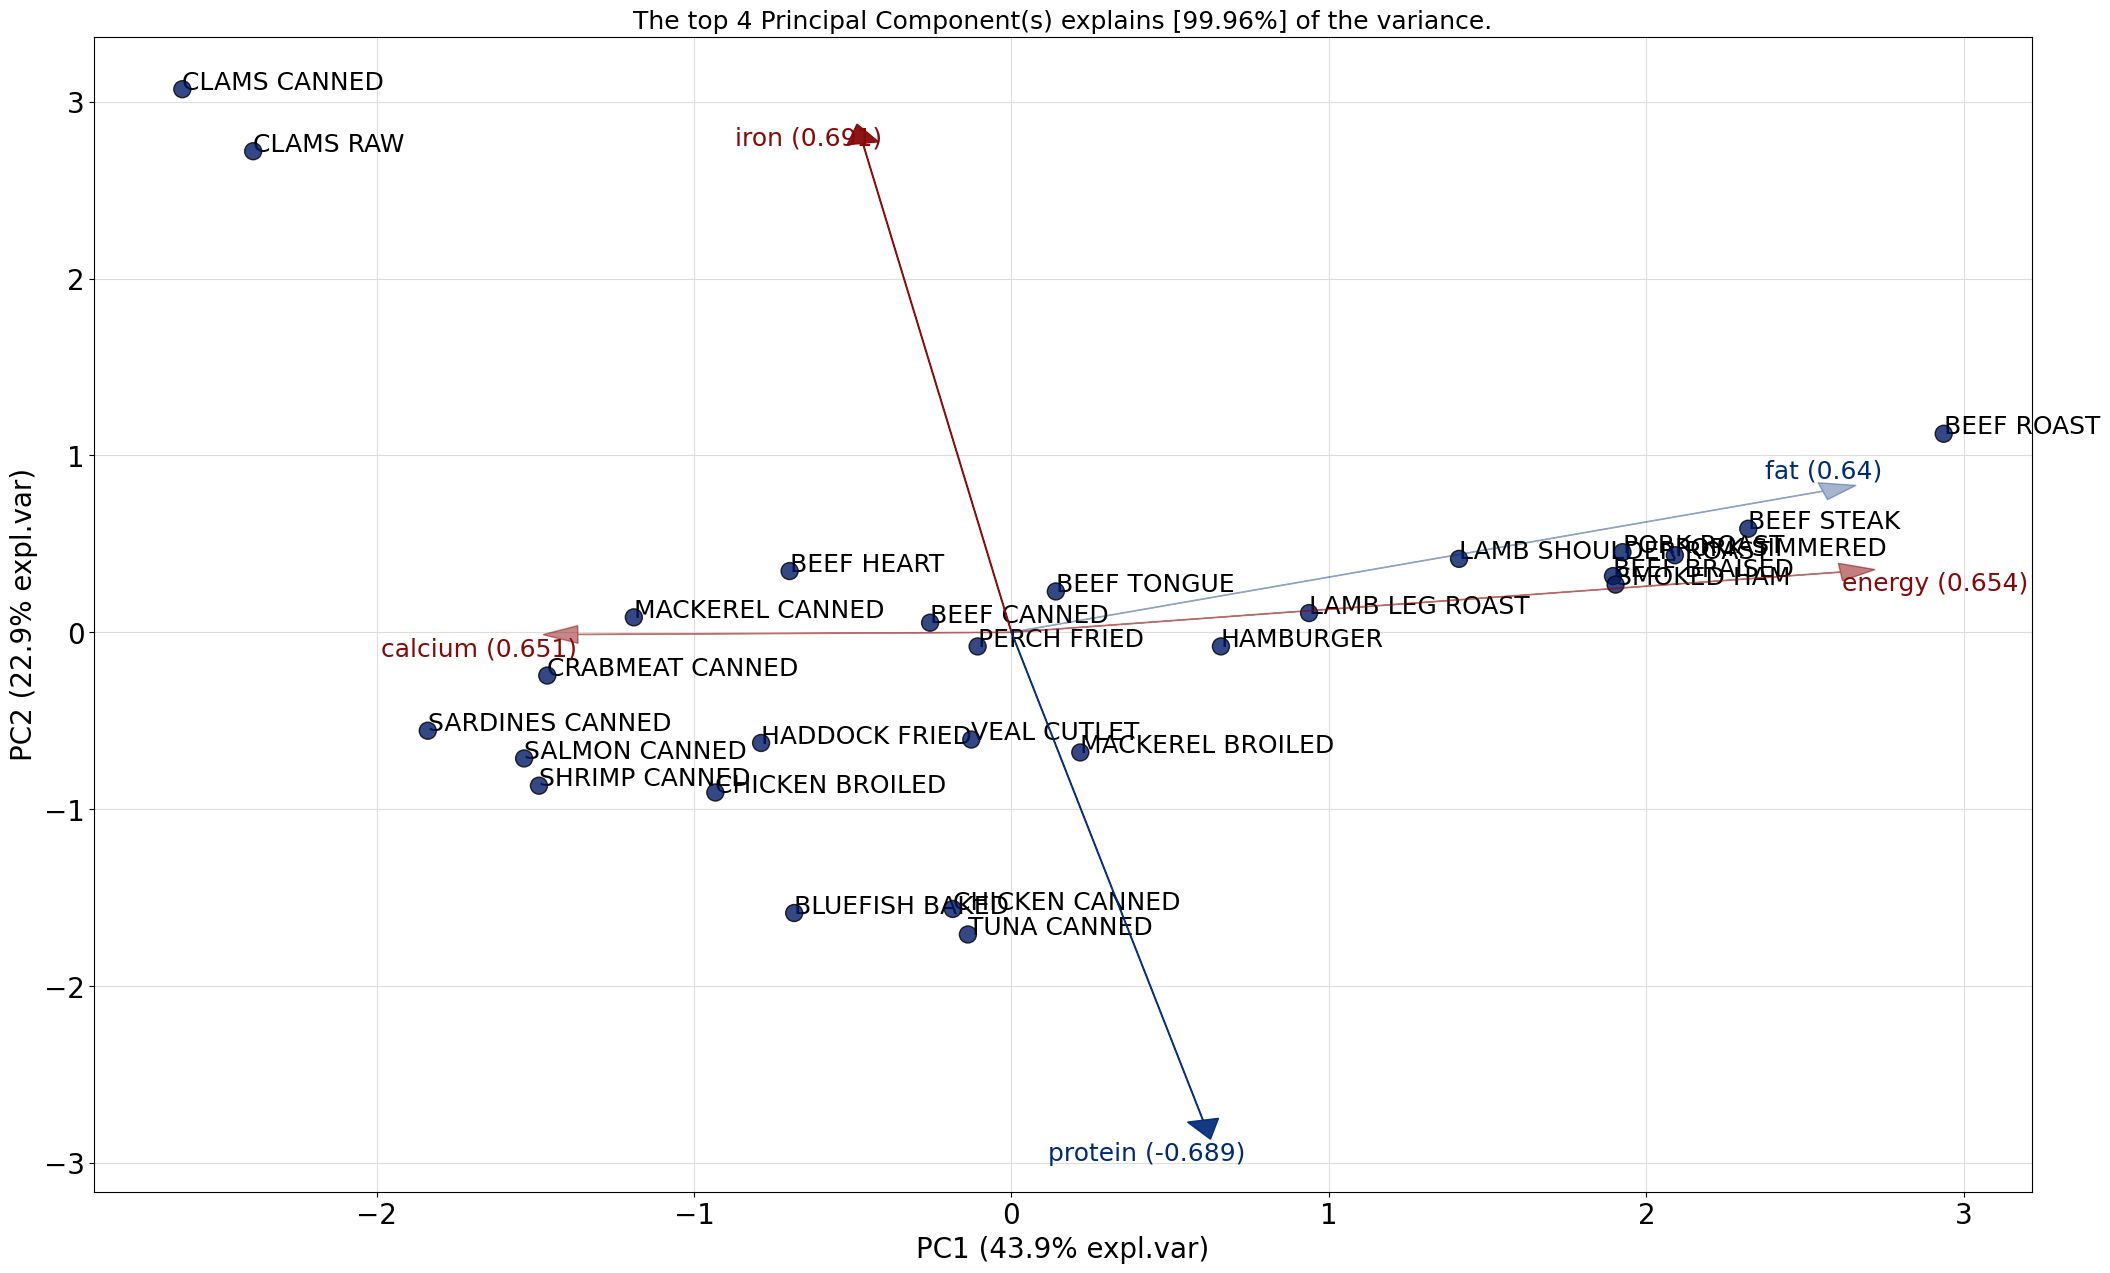

In [39]:
model = pca()
results = model.fit_transform(nut_scaled,
                             col_labels = nut.columns,
                             row_labels = list(nut.index))
model.biplot(label=True, legend=True)
for i in np.arange(0, nut.shape[0]):
    plt.text(pc_data.values[i,0],
            pc_data.values[i,1],
            list(nut.index)[i])
plt.show()

# US Arrest Dataset

In [40]:
usa = pd.read_csv("USArrests.csv", index_col=0)
usa.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [41]:
scaler = StandardScaler().set_output(transform='pandas')
usa_scaled = scaler.fit_transform(usa)

In [42]:
prcomp = PCA().set_output(transform='pandas')
pc_data = prcomp.fit_transform(usa_scaled)
pc_data.var()   #PC0 > PC1 > .....> PC4

pca0    2.530859
pca1    1.009964
pca2    0.363840
pca3    0.176969
dtype: float64

[24-04-2026 16:28:07] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 4 columns of the input data.
[24-04-2026 16:28:07] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute explained variance.
[24-04-2026 16:28:07] [pca.pca] [INFO] The top 3 principal component(s) explains >= 95.00% of the explained variance.
[24-04-2026 16:28:07] [pca.pca] [INFO] The PCA reduction is performed on 4 variables (columns) of the input dataframe.
[24-04-2026 16:28:07] [pca.pca] [INFO] Fit using PCA.
[24-04-2026 16:28:07] [pca.pca] [INFO] Compute loadings and PCs.
[24-04-2026 16:28:07] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[24-04-2026 16:28:08] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[24-04-2026 16:28:08] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[24

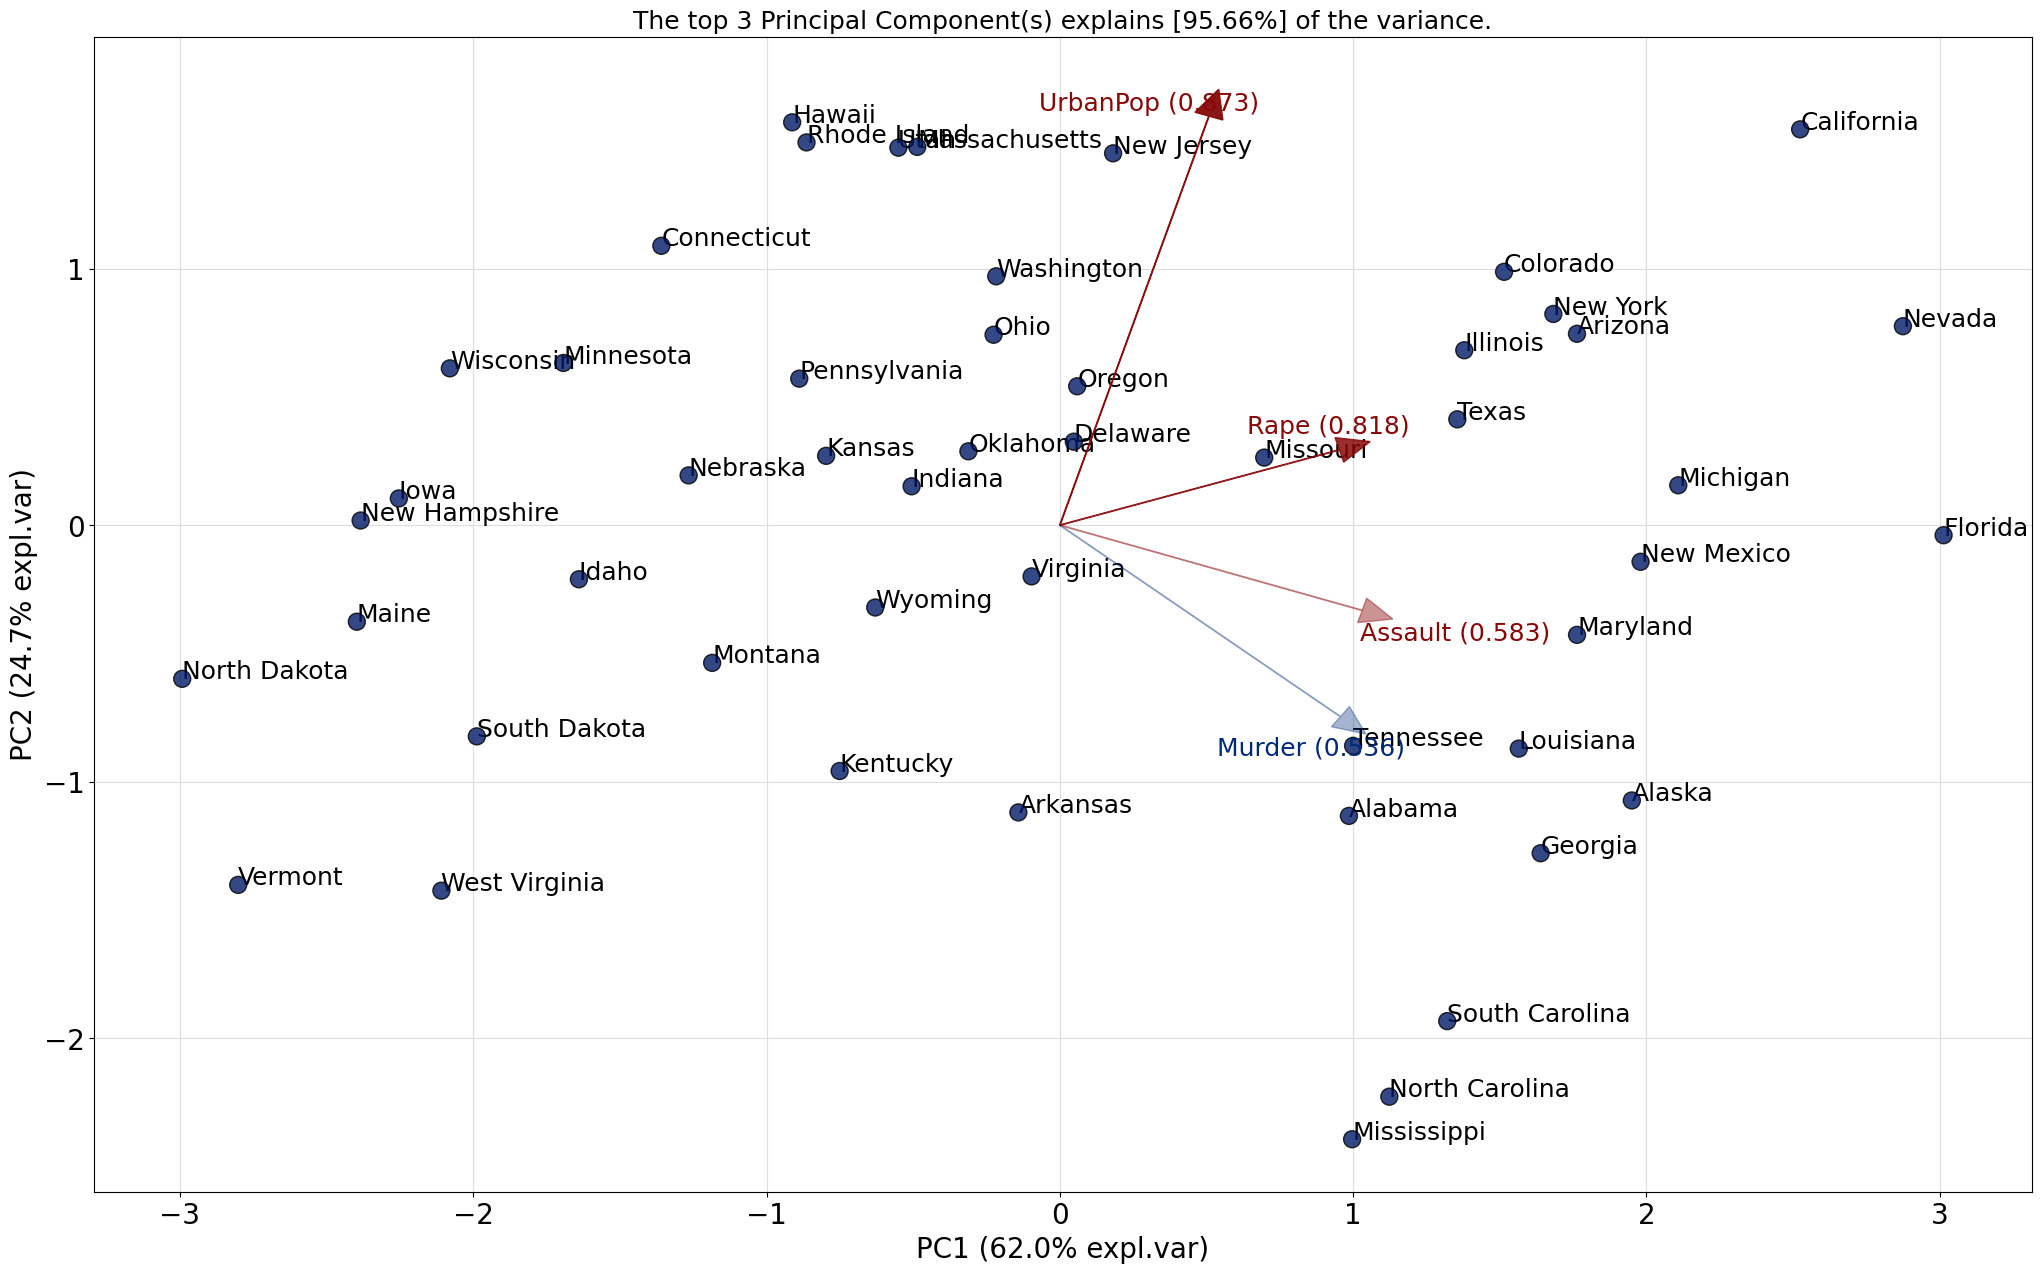

In [43]:
model = pca()
results = model.fit_transform(usa_scaled,
                             col_labels = usa.columns,
                             row_labels = list(usa.index))
model.biplot(label=True, legend=True)
for i in np.arange(0, usa.shape[0]):
    plt.text(pc_data.values[i,0],
            pc_data.values[i,1],
            list(usa.index)[i])
plt.show()